# FLUXNET ecosystem fluxes: one site, the right aggregation

The [ICOS FLUXNET release](https://doi.org/10.18160/S6TB-567H) is served at
`https://zarr.icos-cp.eu/icos-fluxnet.zarr`, one group per site with one
subgroup per aggregation: `fluxnet_dd` (daily), `fluxnet_ww`, `fluxnet_mm`,
`fluxnet_yy`. **Open the aggregation you need** — never resample daily data to
months yourself; the aggregated groups carry the correct QC fractions.

This notebook reads Hyltemossa (SE-Htm, a spruce forest in southern Sweden) at
monthly resolution. Two conventions to know:

- Carbon fluxes come as small labelled **cubes**: `NEE(time, ustar_threshold,
  nee_variant)` and `GPP`/`RECO(time, partition_method, ustar_threshold,
  nee_variant)`. The standard reference slice is `VUT`/`REF` (+ `NT` or `DT`
  partition for GPP/RECO).
- Aggregated QC is a **fraction** of good half-hours — keep values with
  `NEE_QC > 0.3`, not an integer flag. GPP and RECO carry **no QC of their
  own** (they are *partitioned from* NEE), so mask all three fluxes with
  `NEE_QC`.

In [1]:
import numpy as np, pandas as pd, xarray as xr

ds = xr.open_zarr("https://zarr.icos-cp.eu/icos-fluxnet.zarr/SE-Htm/fluxnet_mm",
                  consolidated=True)
print(str(ds.time.values[0])[:10], "→", str(ds.time.values[-1])[:10],
      f"({ds.sizes['time']} months)")
print("cube dims:", dict(ds["GPP"].sizes))

2018-01-01 → 2025-12-01 (96 months)
cube dims: {'time': 96, 'partition_method': 2, 'ustar_threshold': 2, 'nee_variant': 11}


In [2]:
# The reference slice, QC-masked. The quality fraction lives on NEE (the
# measured flux); GPP and RECO are partitioned FROM it, so one mask serves all.
sel_nee = dict(ustar_threshold="VUT", nee_variant="REF")
sel_gpp = dict(partition_method="NT", **sel_nee)
good = ds["NEE_QC"].sel(**sel_nee) > 0.3      # fraction of good half-hours

nee  = ds["NEE"].sel(**sel_nee).where(good)
gpp  = ds["GPP"].sel(**sel_gpp).where(good)
reco = ds["RECO"].sel(**sel_gpp).where(good)
t = pd.to_datetime(ds.time.values)
print("units:", ds["NEE"].attrs.get("units"),
      "| months kept:", int(good.sum()), "of", good.size)

units: umol m-2 s-1 | months kept: 92 of 96


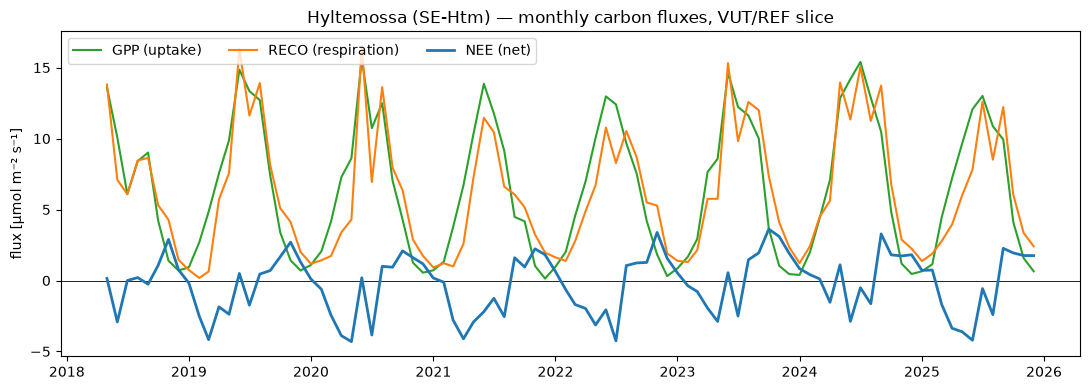

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(0, color="k", lw=0.6)
ax.plot(t, gpp.values,  color="tab:green",  label="GPP (uptake)")
ax.plot(t, reco.values, color="tab:orange", label="RECO (respiration)")
ax.plot(t, nee.values,  color="tab:blue",   lw=2, label="NEE (net)")
ax.set_ylabel("flux [µmol m⁻² s⁻¹]")
ax.set_title("Hyltemossa (SE-Htm) — monthly carbon fluxes, VUT/REF slice")
ax.legend(loc="upper left", ncols=3)
fig.tight_layout()

In [4]:
# Negative NEE = net carbon uptake. When did the forest take up most carbon?
s = pd.Series(nee.values, index=t).dropna()
print("strongest uptake months:")
print(s.nsmallest(5).round(2).to_string())
print()
print("citation:", ds.attrs["citation"][:180], "…")

strongest uptake months:
2020-05-01   -4.31
2022-07-01   -4.25
2025-06-01   -4.21
2019-03-01   -4.17
2021-04-01   -4.11

citation: Heliasz, M., Kljun, N., Biermann, T., Holst, J., Holst, T., Kornacher, P., Linderson, M., Molder, M., Rinne, J. (2026). ETC L2 ARCHIVE from Hyltemossa, 2018–2025, ICOS RI, https:// …


**All 43 sites at once**: the `_combined/fluxnet_mm` group stacks every
site on a `station` dimension — or use the REST API
(`id=icos-fluxnet._combined-fluxnet_dd.GPP_NT_VUT_REF`) for filtered extracts
with a data passport, exactly as in notebook 03.